# Explainable AI Lab: Local Explanations with **LIME**
### Dataset: Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository (ID = 17)



---

## Learning Objectives

By the end of this notebook you should be able to:

1. Load a benchmark dataset directly from the **UCI ML Repository** and prepare it for modelling.
2. Train and evaluate a **black-box classifier** (Random Forest) against an interpretable baseline (Logistic Regression).
3. Explain the **mathematical formulation** of LIME (Local Interpretable Model-agnostic Explanations).
4. Generate and *correctly read* **local explanations** for individual predictions.
5. Diagnose **misclassifications** using explanations rather than guesswork.
6. Assess the **local fidelity** and **stability** of an explanation — the two properties most students forget to check.
7. Articulate the **limitations** of LIME and how it compares with SHAP.

## Prerequisites
Python, `numpy`/`pandas`, basic supervised learning, elementary linear algebra and probability.

## 1. Motivation — The Black-Box Problem

A Random Forest with 500 trees may achieve 96% accuracy on cancer diagnosis, but a clinician cannot act on
"the ensemble said malignant". Regulations such as the EU GDPR *right to explanation* and, in India,
the DPDP Act's transparency obligations, make this a practical engineering requirement, not a philosophical one.

Interpretability methods split along two axes:

| Axis | Option A | Option B |
|---|---|---|
| **Scope** | **Global** — how the model behaves overall (e.g. permutation importance) | **Local** — why *this one* prediction was made (LIME, SHAP) |
| **Coupling** | **Model-specific** — needs internals (tree paths, gradients) | **Model-agnostic** — only needs `predict_proba` |

> **LIME is local + model-agnostic.** It answers: *"Which features pushed the model towards this label, for this particular patient?"*

A high global importance for `worst area` does **not** mean `worst area` drove *this* patient's prediction.
That gap is exactly why local methods exist.

In [3]:
# Run once if the packages are missing. Restart the kernel afterwards.
!pip install -q lime ucimlrepo scikit-learn pandas matplotlib seaborn

In [4]:
import warnings, sys
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid")

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
import sklearn; print("scikit-learn:", sklearn.__version__)
print("LIME        :", lime.__version__ if hasattr(lime, "__version__") else "installed")

Python      : 3.13.15
NumPy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1
LIME        : installed


## 2. The Dataset — Breast Cancer Wisconsin (Diagnostic)

| Property | Value |
|---|---|
| UCI ID | **17** |
| Instances | 569 |
| Features | 30 numeric, real-valued |
| Target | Diagnosis: **M** = malignant, **B** = benign |
| Missing values | None |
| Task | Binary classification |

Features are computed from a digitised image of a **fine needle aspirate (FNA)** of a breast mass.
Ten base measurements are taken for each cell nucleus — *radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension* — and for each of these the
**mean**, **standard error** and **worst** (mean of the three largest values) are recorded, giving 10 × 3 = 30 features.

**Encoding convention used throughout this notebook:** `1 = Malignant` (the positive / clinically important class),
`0 = Benign`. Note that scikit-learn's bundled copy uses the *opposite* convention, so we invert it for consistency.

In [5]:
def load_uci_breast_cancer(verbose=True):
    # Primary path : fetch live from the UCI ML Repository via the official `ucimlrepo` API.
    # Fallback path: identical copy bundled with scikit-learn (for offline / firewalled labs).
    # Returns: X (DataFrame), y (1 = Malignant), feature_names, class_names, source
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=17)                 # 17 = Breast Cancer Wisconsin (Diagnostic)
        X = ds.data.features.copy()
        y_raw = ds.data.targets.iloc[:, 0]
        y = (y_raw.astype(str).str.upper().str[0] == "M").astype(int).to_numpy()
        source = "UCI ML Repository (live fetch, id=17)"
        if verbose:
            print(ds.metadata["name"], "|", ds.metadata["abstract"][:90], "...")
    except Exception as e:
        from sklearn.datasets import load_breast_cancer
        if verbose:
            print(f"[!] Live UCI fetch unavailable ({type(e).__name__}). "
                  f"Falling back to the identical scikit-learn copy.")
        d = load_breast_cancer(as_frame=True)
        X = d.data.copy()
        y = 1 - d.target.to_numpy()               # invert: sklearn uses 0=malignant
        source = "scikit-learn bundled copy of UCI dataset 17"

    X.columns = [c.strip() for c in X.columns]
    return X, y, list(X.columns), ["Benign", "Malignant"], source


X, y, feature_names, class_names, SOURCE = load_uci_breast_cancer()

print("\nSource     :", SOURCE)
print("Shape      :", X.shape)
print("Classes    :", dict(zip(class_names, np.bincount(y))))
print("Malignant %: {:.1f}%".format(100 * y.mean()))
X.head()

Breast Cancer Wisconsin (Diagnostic) | Diagnostic Wisconsin Breast Cancer Database. ...

Source     : UCI ML Repository (live fetch, id=17)
Shape      : (569, 30)
Classes    : {'Benign': np.int64(357), 'Malignant': np.int64(212)}
Malignant %: 37.3%


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Quick sanity checks — always do these before modelling
print("Missing values :", int(X.isna().sum().sum()))
print("Duplicate rows :", int(X.duplicated().sum()))
print("Dtypes         :", set(map(str, X.dtypes)))

display(X.iloc[:, :6].describe().T.round(3))

Missing values : 0
Duplicate rows : 0
Dtypes         : {'float64'}


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
texture1,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
perimeter1,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
area1,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
smoothness1,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
compactness1,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345


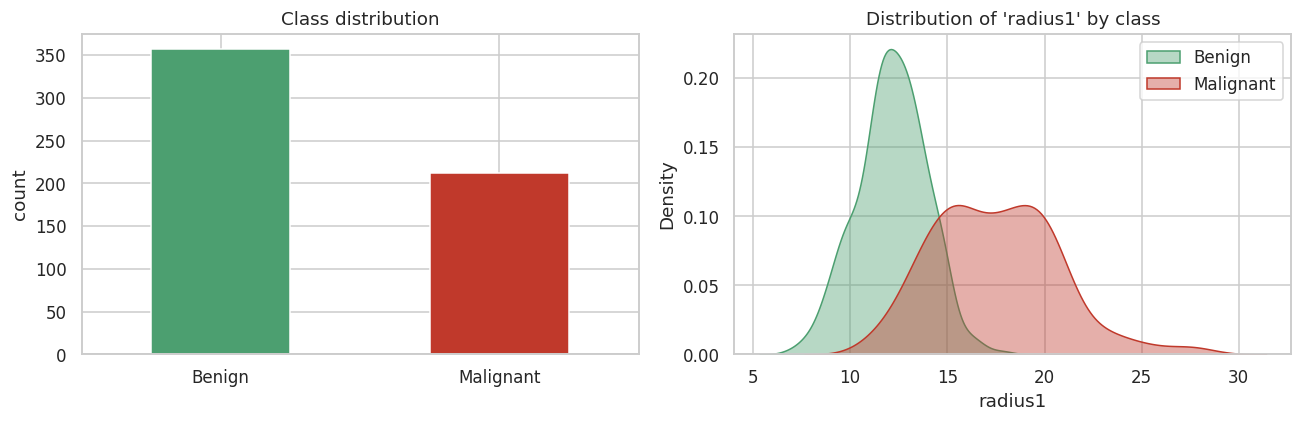

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) class balance
pd.Series(y).map({0: "Benign", 1: "Malignant"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C9F70", "#C0392B"], rot=0)
axes[0].set_title("Class distribution"); axes[0].set_ylabel("count")

# (b) one discriminative feature
col = feature_names[0]   # 'mean radius' / 'radius1'
for lab, name, c in [(0, "Benign", "#4C9F70"), (1, "Malignant", "#C0392B")]:
    sns.kdeplot(X.loc[y == lab, col], ax=axes[1], fill=True, alpha=.4, label=name, color=c)
axes[1].set_title(f"Distribution of '{col}' by class"); axes[1].legend()
plt.tight_layout(); plt.show()

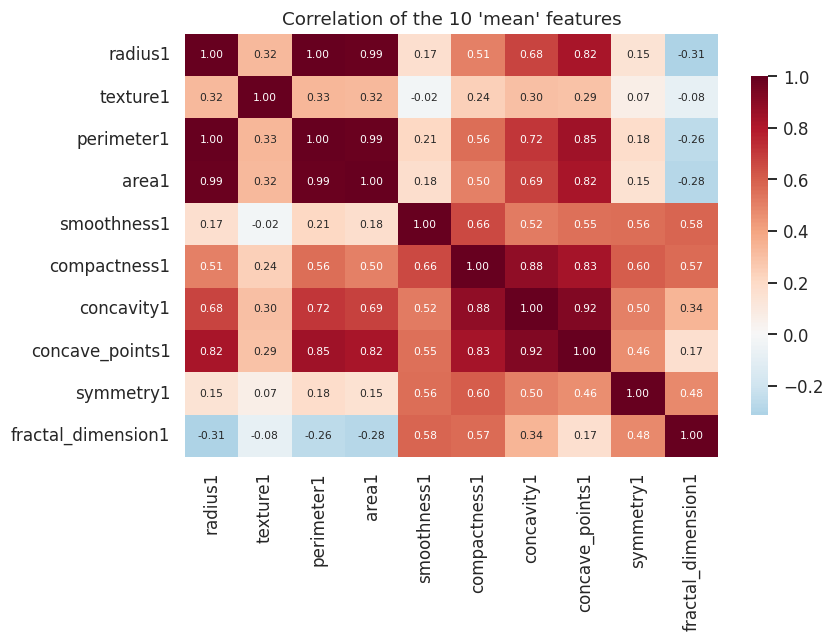

In [8]:
# Correlation among the first 10 (the "mean") features — note the strong block structure.
plt.figure(figsize=(8, 6))
sns.heatmap(X.iloc[:, :10].corr(), cmap="RdBu_r", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Correlation of the 10 'mean' features")
plt.tight_layout(); plt.show()

> **Observation to carry forward.** `radius`, `perimeter` and `area` are almost perfectly correlated
> (r ≈ 0.99) — they are geometrically redundant. **Correlated features are LIME's known weak spot**:
> credit for a prediction gets split arbitrarily among them, and perturbation generates unrealistic
> synthetic points (a cell with a large radius but tiny area). Keep this in mind in Section 9.

## 3. Train / Test Split and a Critical Design Decision

**Where should the scaler live?**

LIME perturbs data **in the feature space you hand to the explainer** and reports weights in
those same units. If you scale first and pass standardised data, every explanation reads
`worst area <= -0.42` — meaningless to a clinician.

✅ **Correct pattern:** keep the scaler *inside* an sklearn `Pipeline`, give LIME the **raw** training data,
and pass `pipeline.predict_proba` as the prediction function. The pipeline scales internally; the
explanation stays in original units (mm, µm², …).

Tree ensembles do not need scaling at all, so our Random Forest consumes raw features directly.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]} samples  ({100*y_train.mean():.1f}% malignant)")
print(f"Test : {X_test.shape[0]} samples  ({100*y_test.mean():.1f}% malignant)")

# LIME works on NumPy arrays
X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()

Train: 426 samples  (37.3% malignant)
Test : 143 samples  (37.1% malignant)


## 4. Models: an Interpretable Baseline vs. a Black Box

We deliberately train two models:

* **Logistic Regression** — *intrinsically interpretable*. Its coefficients ARE a global explanation.
  This is our reference point; if it matched the Random Forest's accuracy we would not need LIME at all.
* **Random Forest (400 trees)** — *black box*. No single coefficient exists; the decision is spread
  over thousands of split conditions. This is the model we will explain.

In [10]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=SEED))
])

rf = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=2,
    n_jobs=-1, random_state=SEED)

logreg.fit(X_train_np, y_train)
rf.fit(X_train_np, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, model in [("Logistic Regression", logreg), ("Random Forest", rf)]:
    s = cross_val_score(model, X_train_np, y_train, cv=cv, scoring="roc_auc")
    print(f"{name:22s}  5-fold CV ROC-AUC = {s.mean():.4f} (+/- {s.std():.4f})")

Logistic Regression     5-fold CV ROC-AUC = 0.9914 (+/- 0.0090)
Random Forest           5-fold CV ROC-AUC = 0.9874 (+/- 0.0089)


In [11]:
def evaluate(model, name):
    y_pred  = model.predict(X_test_np)
    y_proba = model.predict_proba(X_test_np)[:, 1]
    print(f"\n{'='*58}\n{name}\n{'='*58}")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3))
    return y_pred, y_proba

_,        proba_lr = evaluate(logreg, "Logistic Regression (interpretable baseline)")
y_pred_rf, proba_rf = evaluate(rf,    "Random Forest (black box -> to be explained)")


Logistic Regression (interpretable baseline)
Accuracy : 0.9650
ROC-AUC  : 0.9962

              precision    recall  f1-score   support

      Benign      0.957     0.989     0.973        90
   Malignant      0.980     0.925     0.951        53

    accuracy                          0.965       143
   macro avg      0.968     0.957     0.962       143
weighted avg      0.966     0.965     0.965       143


Random Forest (black box -> to be explained)
Accuracy : 0.9650
ROC-AUC  : 0.9960

              precision    recall  f1-score   support

      Benign      0.947     1.000     0.973        90
   Malignant      1.000     0.906     0.950        53

    accuracy                          0.965       143
   macro avg      0.974     0.953     0.962       143
weighted avg      0.967     0.965     0.965       143



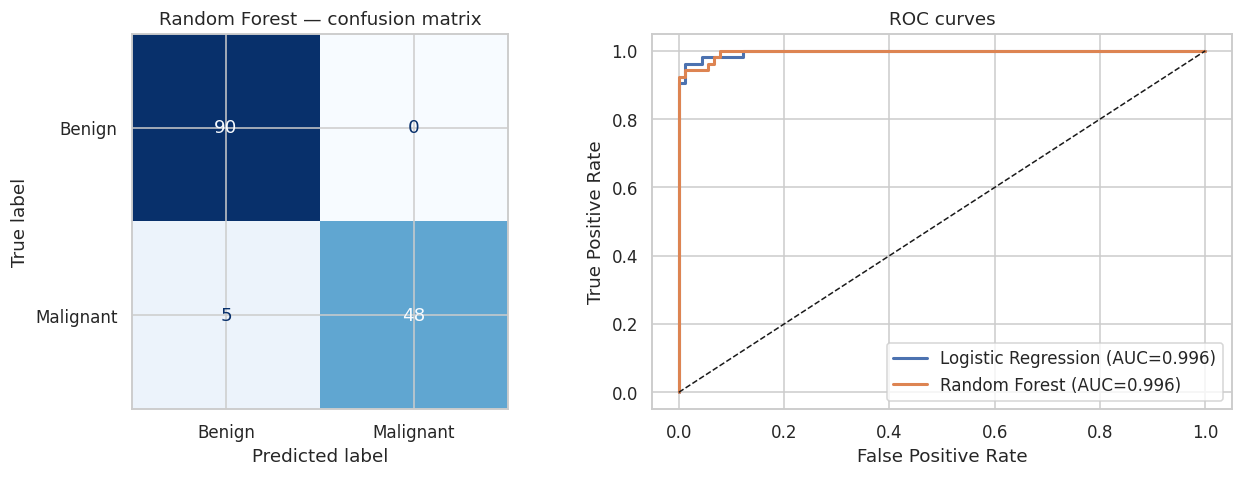

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=class_names).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Random Forest — confusion matrix")

for nm, pr in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{nm} (AUC={roc_auc_score(y_test, pr):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC curves"); axes[1].legend(loc="lower right")

plt.tight_layout(); plt.show()

> In a screening context a **false negative** (malignant predicted benign) is far costlier than a false
> positive. Note the recall on the *Malignant* row above — that, not accuracy, is the number that matters.
> In Section 7 we will use LIME to interrogate exactly these errors.

## 5. How LIME Works — The Theory

### 5.1 Core idea
A complex decision boundary $f$ can be wildly non-linear **globally**, yet be well approximated by a
**straight line in a small neighbourhood** of a single point $x$. LIME fits that local line.

### 5.2 The optimisation problem

$$\xi(x) \;=\; \underset{g \in G}{\arg\min}\; \mathcal{L}\big(f,\, g,\, \pi_x\big) \;+\; \Omega(g)$$

| Symbol | Meaning |
|---|---|
| $f$ | the black-box model (Random Forest); we only query `f.predict_proba` |
| $G$ | class of interpretable models — here **sparse linear regression** |
| $g \in G$ | the local surrogate we fit and show to the user |
| $\pi_x(z)$ | proximity kernel weighting a perturbed sample $z$ by closeness to $x$ |
| $\mathcal{L}$ | weighted squared loss between $f(z)$ and $g(z')$ — the **infidelity** |
| $\Omega(g)$ | complexity penalty — here "use at most $K$ features" (via LASSO path) |

The **exponential kernel** with width $\sigma$:

$$\pi_x(z) \;=\; \exp\!\left(-\,\frac{D(x, z)^2}{\sigma^{2}}\right)$$

and the loss actually minimised:

$$\mathcal{L}(f, g, \pi_x) \;=\; \sum_{z, z' \in \mathcal{Z}} \pi_x(z)\,\big(f(z) - g(z')\big)^{2}$$

### 5.3 Algorithm (tabular data)

1. **Perturb** — draw $N$ (default 5000) synthetic samples around $x$ by sampling each feature from
   $\mathcal{N}(\mu_j, \sigma_j)$ estimated on the training set, then re-centre on $x$.
2. **Label** — query the black box: $f(z)$ for every synthetic sample. *This is the only access LIME needs.*
3. **Weight** — compute $\pi_x(z)$; samples near $x$ dominate the fit.
4. **Select** — pick $K$ features (forward selection / LASSO path).
5. **Fit** — weighted ridge regression of $f(z)$ on the $K$ features.
6. **Report** — the coefficients of $g$ are the explanation.

### 5.4 Discretisation — the part students misread
By default `discretize_continuous=True` bins each continuous feature into quartiles. The surrogate then
operates on **binary indicators** ("is this feature in bin 3?"), which is why explanations read as
`worst perimeter > 125.40` rather than as a slope. The weight answers:

> *"Given that this feature falls in **this bin**, how much probability mass is added to / removed from the predicted class?"*

Set `discretize_continuous=False` if you want raw continuous coefficients instead.

In [13]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data      = X_train_np,     # RAW units -> readable explanations
    feature_names      = feature_names,
    class_names        = class_names,
    mode               = "classification",
    discretize_continuous = True,        # quartile bins -> "feature > 125.40"
    discretizer        = "quartile",
    random_state       = SEED,
    verbose            = False
)
print("Explainer ready. Statistics estimated from", X_train_np.shape[0], "training rows.")

Explainer ready. Statistics estimated from 426 training rows.


## 6. Explaining a Single Prediction

We pick a confidently-predicted **malignant** test case and ask the Random Forest to justify itself.

In [14]:
# choose a high-confidence malignant prediction
mal_idx  = np.where((y_test == 1) & (proba_rf > 0.95))[0]
idx      = int(mal_idx[0])
x        = X_test_np[idx]

print(f"Test instance #{idx}")
print(f"  True label      : {class_names[y_test[idx]]}")
print(f"  RF prediction   : {class_names[y_pred_rf[idx]]}")
print(f"  P(Malignant)    : {proba_rf[idx]:.4f}")

Test instance #0
  True label      : Malignant
  RF prediction   : Malignant
  P(Malignant)    : 0.9509


In [15]:
exp = explainer.explain_instance(
    data_row      = x,
    predict_fn    = rf.predict_proba,
    num_features  = 10,      # K in Omega(g)
    num_samples   = 5000,    # N perturbations
    labels        = (1,)     # explain the "Malignant" class
)

print(f"{'Rule (condition on the instance)':<42} {'Weight':>9}  Direction")
print("-" * 72)
for rule, w in exp.as_list(label=1):
    arrow = "-> Malignant" if w > 0 else "-> Benign"
    print(f"{rule:<42} {w:>+9.4f}  {arrow}")

Rule (condition on the instance)              Weight  Direction
------------------------------------------------------------------------
area3 > 1123.25                              +0.1288  -> Malignant
perimeter3 > 126.85                          +0.1158  -> Malignant
concave_points3 > 0.16                       +0.1055  -> Malignant
radius3 > 19.19                              +0.1053  -> Malignant
concave_points1 > 0.07                       +0.0849  -> Malignant
concavity1 > 0.13                            +0.0546  -> Malignant
area1 > 796.65                               +0.0470  -> Malignant
area2 > 45.39                                +0.0462  -> Malignant
radius1 > 15.98                              +0.0382  -> Malignant
texture1 > 21.82                             +0.0329  -> Malignant


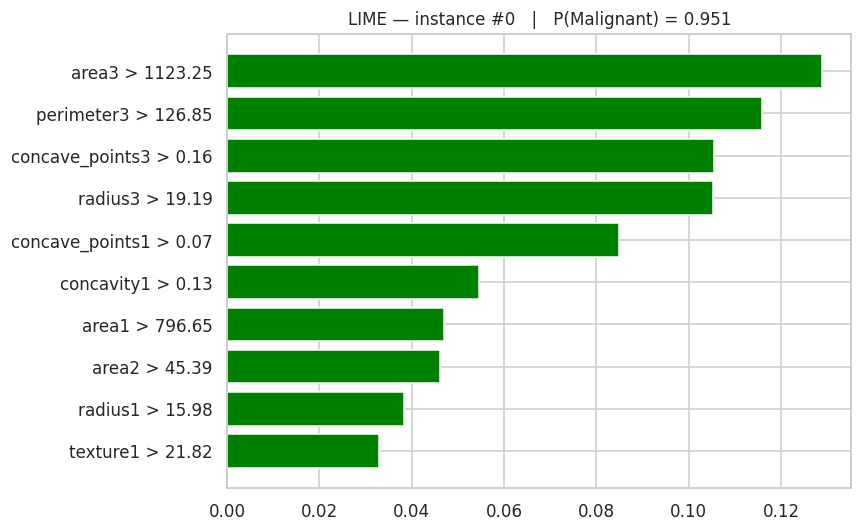

In [16]:
fig = exp.as_pyplot_figure(label=1)
fig.set_size_inches(8, 5)
plt.title(f"LIME — instance #{idx}   |   P(Malignant) = {proba_rf[idx]:.3f}", fontsize=11)
plt.tight_layout(); plt.show()

In [17]:
!pip install -U lime ipywidgets

In [18]:
# Rich interactive HTML view. Renders inside Jupyter / Colab.
# Some LIME + IPython version combinations break on this call, so we guard it:
# the explanation itself is unaffected, only this rendering widget.
try:
    exp.show_in_notebook(show_table=True, show_all=False)
except Exception as err:
    print(f"[!] Interactive widget unavailable ({type(err).__name__}). Saving to HTML instead.")
    exp.save_to_file("lime_explanation.html")
    print("    -> open 'lime_explanation.html' in a browser.")
    print("    -> the matplotlib figure above shows the same information.")

### How to read this plot

* **Green / positive weight** → the condition pushed the prediction **towards Malignant**.
* **Red / negative weight** → it pushed **towards Benign**.
* **Bar length** = magnitude of the local contribution, in units of predicted probability.
* The side table shows the instance's **actual feature values** that triggered each condition.

The local surrogate is, approximately:

$$\hat{p}(\text{Malignant}) \;\approx\; b_0 \;+\; \sum_{k=1}^{K} w_k \cdot \mathbb{1}[\text{condition}_k \text{ holds}]$$

⚠️ **Do not over-claim.** These weights are *associational and local*. "`worst perimeter > 125.4` contributed
+0.21" means the model relied on it here — **not** that enlarging the perimeter would cause cancer.
LIME explains the **model**, not the disease.

## 7. Contrastive Analysis — Benign vs Malignant, and a Failure Case

Explaining one instance is a demo. Explaining *contrasts* is analysis.

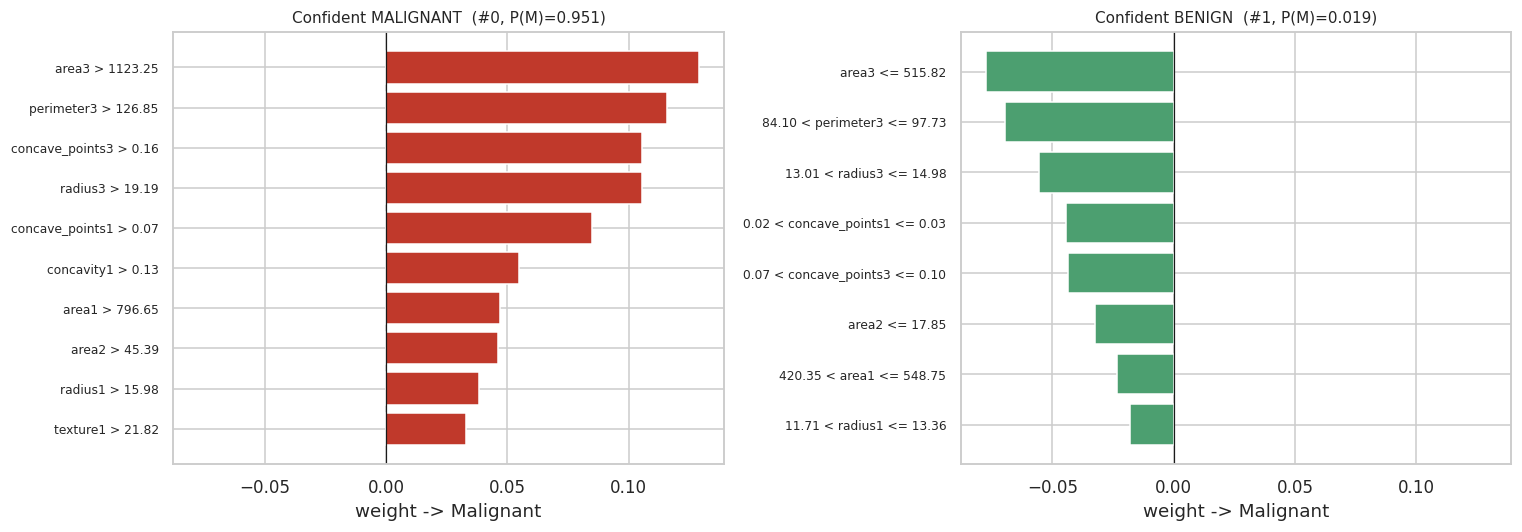

In [19]:
ben_idx = int(np.where((y_test == 0) & (proba_rf < 0.05))[0][0])

exp_ben = explainer.explain_instance(X_test_np[ben_idx], rf.predict_proba,
                                     num_features=8, num_samples=5000, labels=(1,))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, e, i, ttl in [(axes[0], exp,     idx,     "Confident MALIGNANT"),
                      (axes[1], exp_ben, ben_idx, "Confident BENIGN")]:
    items = e.as_list(label=1)[::-1]
    labels = [t for t, _ in items]; vals = [v for _, v in items]
    ax.barh(range(len(vals)), vals,
            color=["#C0392B" if v > 0 else "#4C9F70" for v in vals])
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="k", lw=.8)
    ax.set_title(f"{ttl}  (#{i}, P(M)={proba_rf[i]:.3f})", fontsize=10)
    ax.set_xlabel("weight -> Malignant")
plt.tight_layout(); plt.show()

Notice the **mirror-image structure**: the same family of features (`worst`-suffixed size and concavity
measures) drives both decisions, but the bins flip sign. That consistency is evidence the model has
learned a coherent rule rather than noise.

In [20]:
# --- Debugging errors with LIME ---
errors = np.where(y_pred_rf != y_test)[0]

if len(errors) == 0:
    print("No misclassifications on this split. Inspecting the most UNCERTAIN prediction instead.")
    target = int(np.argmin(np.abs(proba_rf - 0.5)))
    header = "Most uncertain prediction"
else:
    target = int(errors[np.argmax(np.abs(proba_rf[errors] - 0.5))])   # most confidently wrong
    header = "Most confidently WRONG prediction"

print(f"{header}: instance #{target}")
print(f"  True : {class_names[y_test[target]]}")
print(f"  Pred : {class_names[y_pred_rf[target]]}")
print(f"  P(Malignant) = {proba_rf[target]:.4f}\n")

exp_err = explainer.explain_instance(X_test_np[target], rf.predict_proba,
                                     num_features=10, num_samples=5000, labels=(1,))
for rule, w in exp_err.as_list(label=1):
    print(f"  {rule:<42} {w:>+8.4f}")

Most confidently WRONG prediction: instance #111
  True : Malignant
  Pred : Benign
  P(Malignant) = 0.1581

  texture3 <= 21.48                           -0.0471
  texture1 <= 16.34                           -0.0365
  0.23 < concavity3 <= 0.39                   +0.0215
  1.60 < perimeter2 <= 2.30                   -0.0175
  17.85 < area2 <= 24.75                      -0.0162
  684.55 < area3 <= 1123.25                   +0.0149
  548.75 < area1 <= 796.65                    -0.0134
  0.25 < symmetry3 <= 0.28                    -0.0124
  0.09 < compactness1 <= 0.13                 +0.0124
  14.98 < radius3 <= 19.19                    +0.0119


**Diagnostic questions to ask of a failure explanation:**

1. Are the top features *clinically plausible*, or is the model leaning on a spurious proxy?
2. Do the instance's values sit near a **bin boundary** (e.g. just above the 75th percentile)? Borderline
   cases produce fragile explanations.
3. Do positive and negative weights nearly cancel? That signals genuine ambiguity, not a model bug —
   and argues for abstention / referral to a human rather than retraining.

## 8. Local Fidelity — Is the Explanation Even Trustworthy?

An explanation is worthless if the surrogate $g$ does not actually track $f$ near $x$. LIME exposes three
diagnostics, and **you must report them in any serious write-up**:

| Attribute | Meaning | Healthy value |
|---|---|---|
| `exp.score` | $R^2$ of the weighted ridge fit on the perturbed neighbourhood | > 0.6 |
| `exp.local_pred` | surrogate's prediction at $x$ | close to $f(x)$ |
| `exp.intercept` | $b_0$, the local baseline | — |

In [21]:
print(f"Local surrogate R^2      : {exp.score:.4f}")
print(f"Surrogate prediction g(x): {float(np.ravel(exp.local_pred)[0]):.4f}")
print(f"Black-box  f(x)          : {rf.predict_proba(x.reshape(1, -1))[0, 1]:.4f}")
print(f"Local intercept b0       : {exp.intercept[1]:.4f}")

gap = abs(float(np.ravel(exp.local_pred)[0]) - rf.predict_proba(x.reshape(1,-1))[0,1])
print("\nVerdict:", "trustworthy" if (exp.score > 0.6 and gap < 0.15)
      else "treat with caution — poor local fit")

Local surrogate R^2      : 0.6380
Surrogate prediction g(x): 1.0090
Black-box  f(x)          : 0.9509
Local intercept b0       : 0.2497

Verdict: trustworthy


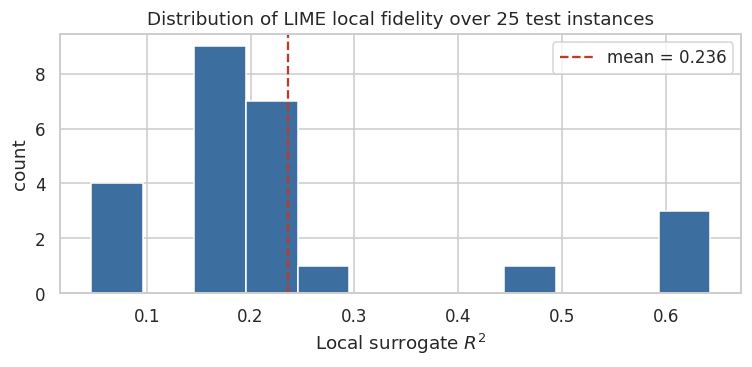

min=0.047  median=0.195  max=0.643


In [22]:
# Fidelity is not uniform across the input space. Measure it over a sample of test points.
rng = np.random.RandomState(SEED)
sample = rng.choice(len(X_test_np), size=25, replace=False)

scores = []
for i in sample:
    e = explainer.explain_instance(X_test_np[i], rf.predict_proba,
                                   num_features=8, num_samples=2000, labels=(1,))
    scores.append(e.score)
scores = np.array(scores)

plt.figure(figsize=(7, 3.5))
plt.hist(scores, bins=12, color="#3C6E9F", edgecolor="white")
plt.axvline(scores.mean(), color="#C0392B", ls="--",
            label=f"mean = {scores.mean():.3f}")
plt.xlabel("Local surrogate $R^2$"); plt.ylabel("count")
plt.title("Distribution of LIME local fidelity over 25 test instances")
plt.legend(); plt.tight_layout(); plt.show()

print(f"min={scores.min():.3f}  median={np.median(scores):.3f}  max={scores.max():.3f}")

### Interpreting a low median $R^2$

You will probably find the median $R^2$ is **well below 0.6** — much lower than for the confident instance
in the previous cell. This is not a bug, and it is one of the most instructive results in this notebook.
Three things are going on:

1. **Saturated predictions.** This model is very accurate, so for most test points $f(z) \approx 1$ or
   $\approx 0$ across the whole neighbourhood. With almost no variance in the target, $R^2$ collapses
   even though the surrogate's *absolute* error is tiny. **Always read $R^2$ alongside
   $|g(x) - f(x)|$** — a flat neighbourhood is easy to approximate but scores badly.
2. **Fewer samples.** We used `num_samples=2000` here versus 5000 above. Fidelity rises with sample size.
3. **Genuinely non-linear regions.** Some points sit near a complex decision boundary where no linear
   surrogate can fit well. Those explanations really should be distrusted.

**Exercise:** re-run the cell with `num_samples=10000` and additionally record
$|g(x) - f(x)|$. Which of the three causes above dominates for this dataset?

## 9. Stability — The Experiment Most Reports Omit

LIME samples randomly. Run it twice on the *same* instance with a *different* seed and you may get
different weights. If your explanation flips between runs, you cannot show it to a clinician.

We run the explainer **10 times** on one instance and measure the spread of each feature's weight.

In [23]:
N_RUNS = 10
runs = []
for r in range(N_RUNS):
    e = lime.lime_tabular.LimeTabularExplainer(
            X_train_np, feature_names=feature_names, class_names=class_names,
            mode="classification", discretize_continuous=True, random_state=100 + r
        ).explain_instance(x, rf.predict_proba, num_features=10,
                           num_samples=5000, labels=(1,))
    runs.append(dict(e.as_list(label=1)))

stab = pd.DataFrame(runs).fillna(0.0)
summary = (pd.DataFrame({"mean": stab.mean(), "std": stab.std(),
                         "appeared_in_runs": (stab != 0).sum()})
             .sort_values("mean", key=np.abs, ascending=False))
summary["CV_%"] = (summary["std"].abs() / summary["mean"].abs().replace(0, np.nan) * 100).round(1)
display(summary.round(4))

,mean,std,appeared_in_runs,CV_%
area3 > 1123.25,0.1266,0.0024,10,1.9
perimeter3 > 126.85,0.1234,0.0015,10,1.2
concave_points3 > 0.16,0.1056,0.0023,10,2.2
radius3 > 19.19,0.1022,0.0034,10,3.4
concave_points1 > 0.07,0.0819,0.0026,10,3.2
concavity1 > 0.13,0.0501,0.0021,10,4.1
radius1 > 15.98,0.0486,0.0028,10,5.7
area2 > 45.39,0.0486,0.0030,10,6.2
area1 > 796.65,0.0461,0.0022,10,4.8
symmetry3 > 0.32,0.0302,0.0160,8,53.0


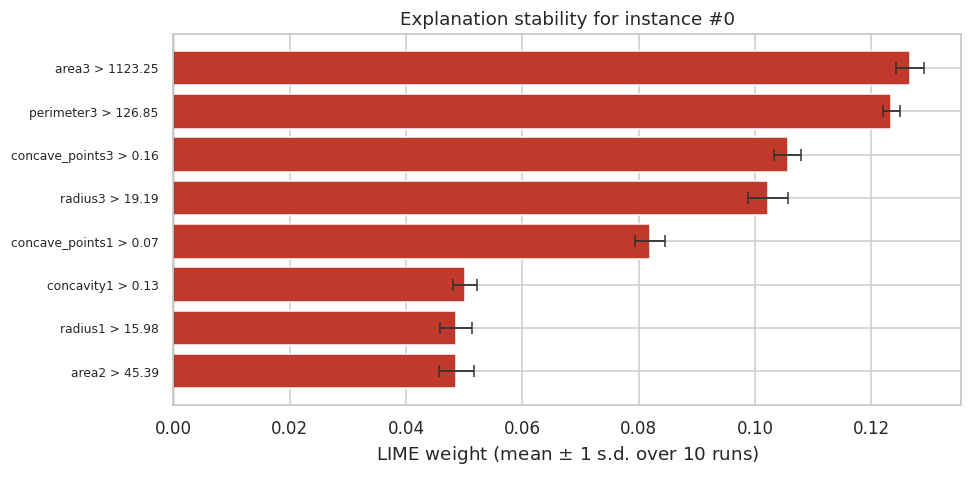

Features appearing in ALL 10 runs (robust):
  area3 > 1123.25
  perimeter3 > 126.85
  concave_points3 > 0.16
  radius3 > 19.19
  concave_points1 > 0.07
  concavity1 > 0.13
  radius1 > 15.98
  area2 > 45.39


In [24]:
top = summary.head(8).iloc[::-1]
plt.figure(figsize=(9, 4.5))
plt.barh(range(len(top)), top["mean"], xerr=top["std"], capsize=4,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in top["mean"]],
         error_kw=dict(ecolor="#333", lw=1.2))
plt.yticks(range(len(top)), top.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("LIME weight (mean $\\pm$ 1 s.d. over 10 runs)")
plt.title(f"Explanation stability for instance #{idx}")
plt.tight_layout(); plt.show()

print("Features appearing in ALL 10 runs (robust):")
print("  " + "\n  ".join(summary.index[summary["appeared_in_runs"] == N_RUNS][:8]))

**Reporting rule for your lab report / thesis:** never present a single LIME run. Report
**mean ± s.d. over ≥ 10 runs**, and state how often each feature survived. Features with a small
`appeared_in_runs` count are artefacts of sampling, not findings.

**Levers that improve stability:** raise `num_samples` (5000 → 15000), reduce `num_features`,
fix `random_state`, or drop one member of each near-collinear feature group (`radius`/`perimeter`/`area`).

## 10. From Local to Global — SP-LIME (Submodular Pick)

One explanation covers one patient. To audit a whole model you would need 143 explanations.
**SP-LIME** selects a small, *non-redundant* set of instances whose explanations jointly cover the
most feature-importance mass — a greedy maximisation of a submodular coverage function
(which guarantees $\geq (1 - 1/e) \approx 63\%$ of the optimum).

In [25]:
from lime import submodular_pick

# NOTE (common bug): SubmodularPick defaults to top_labels=1, so each explanation
# only stores ITS OWN predicted label. A benign instance then has no label 1 and
# `as_list(label=1)` raises KeyError. Pass top_labels=None + labels=(1,) to force
# every instance to be explained w.r.t. the SAME class -> comparable weights.
sp = submodular_pick.SubmodularPick(
    explainer, X_test_np, rf.predict_proba,
    num_features=8, num_exps_desired=3, sample_size=20,
    top_labels=None, labels=(1,))

print(f"SP-LIME selected {len(sp.sp_explanations)} representative instances "
      f"out of {len(X_test_np)} test cases.\n")

for j, e in enumerate(sp.sp_explanations, 1):
    print(f"--- Representative case {j} ---")
    for rule, w in e.as_list(label=1)[:5]:
        print(f"    {rule:<40} {w:>+8.4f}")
    print()

SP-LIME selected 3 representative instances out of 143 test cases.

--- Representative case 1 ---
    area3 <= 515.82                           -0.0795
    perimeter3 <= 84.10                       -0.0713
    radius3 <= 13.01                          -0.0573
    concave_points3 <= 0.07                   -0.0538
    texture3 <= 21.48                         -0.0468

--- Representative case 2 ---
    515.82 < area3 <= 684.55                  -0.0690
    13.01 < radius3 <= 14.98                  -0.0595
    84.10 < perimeter3 <= 97.73               -0.0586
    0.07 < concave_points3 <= 0.10            -0.0569
    texture3 > 30.14                          +0.0490

--- Representative case 3 ---
    area3 > 1123.25                           +0.1294
    perimeter3 > 126.85                       +0.1267
    radius3 > 19.19                           +0.1038
    concave_points1 > 0.07                    +0.0755
    radius1 > 15.98                           +0.0494



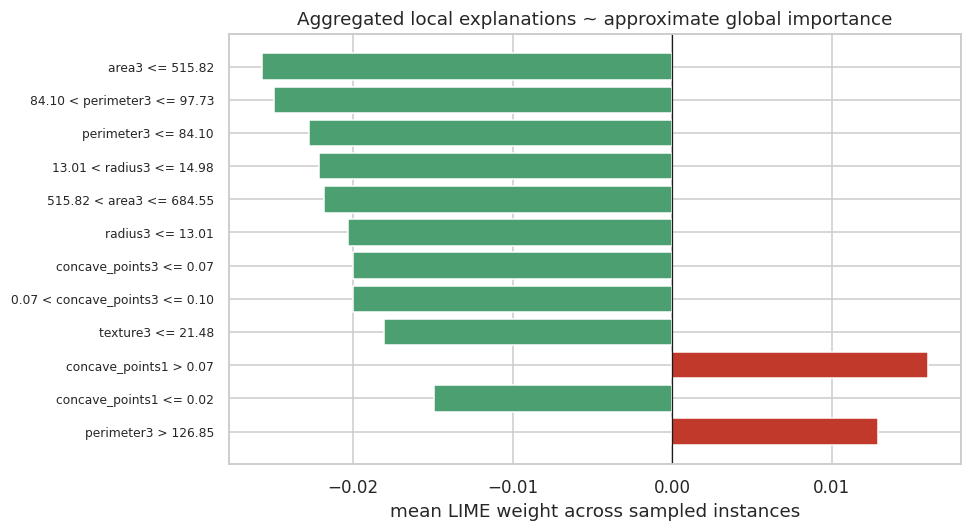

In [26]:
# Aggregate all explanations SP-LIME computed -> an approximate global view
W = pd.DataFrame([dict(e.as_list(label=1)) for e in sp.explanations]).fillna(0)
agg = W.mean().sort_values(key=np.abs, ascending=False).head(12)[::-1]

plt.figure(figsize=(9, 5))
plt.barh(range(len(agg)), agg.values,
         color=["#C0392B" if v > 0 else "#4C9F70" for v in agg.values])
plt.yticks(range(len(agg)), agg.index, fontsize=8)
plt.axvline(0, color="k", lw=.8)
plt.xlabel("mean LIME weight across sampled instances")
plt.title("Aggregated local explanations ~ approximate global importance")
plt.tight_layout(); plt.show()

## 11. Cross-Check: LIME vs. Permutation Importance

A useful validation habit — do the aggregated **local** explanations agree with a genuine **global**
method? Agreement raises confidence; disagreement is a finding worth investigating.

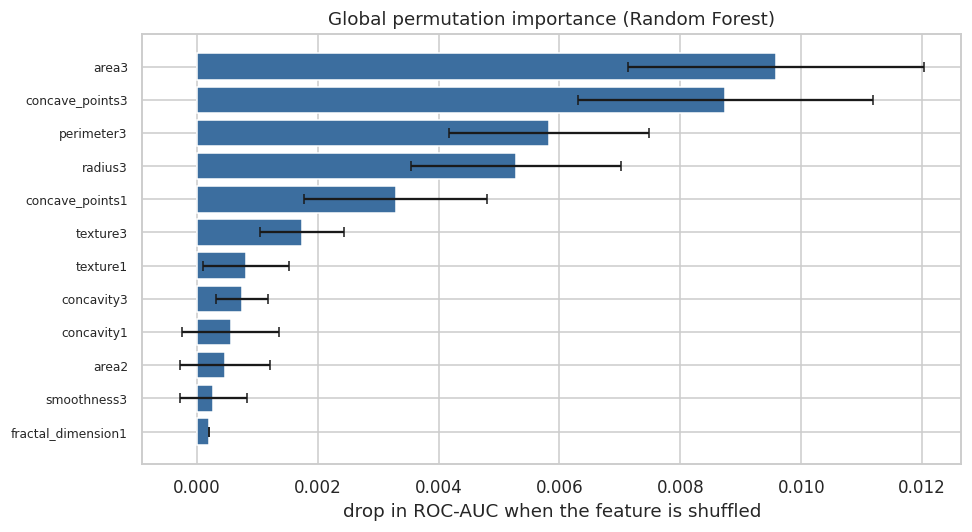

Top-6 GLOBAL (permutation) :
   area3                        0.0096
   concave_points3              0.0087
   perimeter3                   0.0058
   radius3                      0.0053
   concave_points1              0.0033
   texture3                     0.0017

Top-6 aggregated LOCAL (LIME) :
   area3 <= 515.82                          -0.0257
   84.10 < perimeter3 <= 97.73              -0.0250
   perimeter3 <= 84.10                      -0.0227
   13.01 < radius3 <= 14.98                 -0.0221
   515.82 < area3 <= 684.55                 -0.0218
   radius3 <= 13.01                         -0.0203


In [27]:
perm = permutation_importance(rf, X_test_np, y_test, n_repeats=10,
                              random_state=SEED, n_jobs=-1, scoring="roc_auc")

order = np.argsort(perm.importances_mean)[-12:]
plt.figure(figsize=(9, 5))
plt.barh(range(len(order)), perm.importances_mean[order],
         xerr=perm.importances_std[order], color="#3C6E9F", capsize=3)
plt.yticks(range(len(order)), [feature_names[i] for i in order], fontsize=8)
plt.xlabel("drop in ROC-AUC when the feature is shuffled")
plt.title("Global permutation importance (Random Forest)")
plt.tight_layout(); plt.show()

print("Top-6 GLOBAL (permutation) :")
for i in order[::-1][:6]:
    print(f"   {feature_names[i]:<28} {perm.importances_mean[i]:.4f}")

print("\nTop-6 aggregated LOCAL (LIME) :")
for rule, w in agg.iloc[::-1].head(6).items():
    print(f"   {rule:<40} {w:+.4f}")

> Expect **partial** agreement. Permutation importance measures *"how much does test performance
> degrade without this feature?"*; LIME measures *"how much did this feature move THIS prediction?"*.
> They answer different questions, so a rank correlation of ~0.5–0.7 is normal and healthy.
> A near-zero correlation would suggest the local surrogates are fitting noise — go back to Section 8.

## 12. Limitations of LIME, and LIME vs SHAP

### Known weaknesses

| # | Limitation | Practical consequence |
|---|---|---|
| 1 | **Instability** — random sampling | Different runs → different explanations (Section 9) |
| 2 | **Kernel width $\sigma$ is arbitrary** | The default heuristic $\sigma = 0.75\sqrt{d}$ has no theoretical basis; changing it can reverse conclusions |
| 3 | **"Local" is undefined** | No principled answer to *how large* the neighbourhood should be |
| 4 | **Correlated features** | Perturbation creates off-manifold, physically impossible samples; credit is split arbitrarily |
| 5 | **No guarantees** | Contributions do not sum to the prediction (unlike Shapley values) |
| 6 | **Adversarially foolable** | Slack et al. (2020) showed a biased model can be built that hides its bias from LIME |
| 7 | **Cost** | One explanation = `num_samples` model calls; 5000 per instance is expensive at scale |

### Comparison

| Criterion | **LIME** | **SHAP (KernelSHAP / TreeSHAP)** |
|---|---|---|
| Theoretical basis | Local surrogate regression | Shapley values (cooperative game theory) |
| Axioms | none | efficiency, symmetry, dummy, additivity |
| Additivity | ✗ | ✓ contributions sum to $f(x) - \mathbb{E}[f]$ |
| Speed | fast per instance | slow (KernelSHAP); very fast for trees (TreeSHAP) |
| Stability | low–moderate | high |
| Global view | via SP-LIME | native (summary / beeswarm plots) |
| Ease of teaching | ✓ very intuitive | steeper |

**Rule of thumb.** Use LIME for rapid, intuitive, model-agnostic debugging and for text/image data.
Use SHAP when you need theoretical guarantees, additivity, or a defensible audit trail. Best practice
in a thesis: **report both** and discuss where they disagree.

# Assignment: Local Model Explanations Using LIME

## Dataset: Adult / Census Income Dataset

### Objective

Apply **Local Interpretable Model-agnostic Explanations (LIME)** to explain predictions made by a machine-learning classification model on a tabular dataset.

You must use the **Adult/Census Income dataset**, where the objective is to predict whether an individual's annual income is above or below a specified income threshold.

---

# Part A — Dataset Preparation

1. Load the Adult Income dataset and display:
   - Number of instances
   - Number of features
   - Feature names
   - Target variable
   - Numerical features
   - Categorical features

2. Check the dataset for:
   - Missing values
   - Duplicate records
   - Invalid or unknown categorical values
   - Class imbalance

3. Perform appropriate preprocessing for numerical and categorical features.

4. Explain why categorical features require special handling when using `LimeTabularExplainer`.

---

# Part B — Machine Learning Model

5. Split the dataset into training and testing sets using a suitable stratified split.

6. Train the following classification models:

   - Random Forest
   - Logistic Regression

7. Evaluate both models using:

   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - Confusion matrix

8. Compare the performance of the two models.

9. Identify which model should be considered the **black-box model** for the LIME analysis and explain why.

---

# Part C — Applying LIME

10. Create a `LimeTabularExplainer` using the training data.

11. Correctly specify:

```python
feature_names
class_names
categorical_features
categorical_names

# Part D — Interpretation of LIME Explanations

For each of the three selected instances:

### 16. Identify the Top Five Positive Contributors

Identify the **top five features with positive LIME weights** for each instance.

Explain how these features support the predicted class.

---

### 17. Identify the Top Five Negative Contributors

Identify the **top five features with negative LIME weights** for each instance.

Explain how these features oppose or reduce the likelihood of the predicted class.

---

### 18. Interpret the Important Features

Explain in simple language why each of the important features influenced the prediction.

For each feature, discuss:

- Feature value or condition
- LIME weight
- Direction of influence
- Effect on the prediction

---

### 19. Interpretation of a Positive LIME Weight

Answer the following question:

> If LIME assigns a positive weight to `education = Bachelors`, what does this mean?

Explain the meaning of the positive LIME weight in the context of the predicted class.

---

### 20. Difference Between Feature Importance, LIME Weight, and Prediction Probability

Explain the difference between:

- **Feature importance**
- **LIME weight**
- **Model prediction probability**

Discuss how each one should be interpreted and how they are different from one another.

---

### 21. If–Then Style Explanation

Select one of the three instances and convert its LIME explanation into an **if–then style explanation**.

For example:

> **If** the individual's education level is within a particular category and other important feature conditions are satisfied, **then** these conditions contribute toward the model predicting the selected income class.

Use the actual LIME output from your experiment to construct the explanation.

---

# Part E — Misclassification Analysis

### 22. Select an Incorrectly Classified Instance

Select at least **one incorrectly classified test instance**.

Report:

- Actual class
- Predicted class
- Prediction probability
- Important feature values

---

### 23. Generate the LIME Explanation

Generate a LIME explanation for the incorrectly classified instance.

Display the top contributing features and their LIME weights.

---

### 24. Identify the Main Contributors to the Incorrect Prediction

Identify the features that contributed most strongly to the incorrect prediction.

Separate the features into:

- Positive contributors
- Negative contributors

Explain their influence on the model's prediction.

---

### 25. Analyze the Model Error

Discuss whether the LIME explanation provides a possible reason for the model's incorrect prediction.

Consider:

- Which features strongly influenced the prediction?
- Did these features push the model toward the wrong class?
- Was the prediction probability close to the decision boundary?
- Are there conflicting feature contributions?

---

### 26. Can LIME Prove Causation?

Answer the following question:

> Can LIME prove that a particular feature caused the model to make an error? Explain your answer.

Discuss the difference between:

- **Model association**
- **Feature contribution**
- **Causal relationship**

---

# Part F — LIME Stability

LIME uses randomly generated perturbed samples to construct a local explanation. Therefore, the same instance can produce slightly different explanations across different runs.

### 27. Run LIME Multiple Times

Select one test instance and run LIME **10 times** using the same model and instance.

Record the LIME explanation produced during each run.

---

### 28. Record LIME Weights

Record the LIME weights of the **top five features** for every run.

Create a table similar to:

| Run | Feature 1 | Feature 2 | Feature 3 | Feature 4 | Feature 5 |
|---:|---:|---:|---:|---:|---:|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |
| 9 | | | | | |
| 10 | | | | | |

---

### 29. Calculate Stability Measures

Calculate the following for the important features:

- **Mean LIME weight**
- **Standard deviation**
- **Minimum LIME weight**
- **Maximum LIME weight**
- **Number of times the feature appears in the top five**

---

### 30. Visualize LIME Stability

Create a graph showing:

**Feature vs. Mean LIME Weight ± Standard Deviation**

The graph should allow you to compare both:

- Average feature contribution
- Variation in the feature contribution

---

### 31. Identify Stable and Unstable Features

Based on the stability analysis, identify:

1. The most stable feature.
2. The least stable feature.
3. The feature with the highest average contribution.
4. The feature with the largest variation in LIME weight.

---

### 32. Explain Variation in LIME

Explain why LIME explanations may change between different runs.

Consider the role of:

- Random perturbations
- Number of samples
- Local neighbourhood
- Kernel width
- Model complexity

---

### 33. Increase the Number of Samples

Repeat the LIME stability experiment using a larger value of `num_samples`.

Compare the explanations obtained using different numbers of perturbed samples.

---

### 34. Compare Different `num_samples` Values

Compare the stability obtained using:

```text
num_samples = 1,000
num_samples = 5,000
num_samples = 10,000



---



***Assignment-Solution***



---



In [28]:
!pip install -q ucimlrepo lime

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from lime.lime_tabular import LimeTabularExplainer

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully")

Libraries imported successfully


In [30]:
adult = fetch_ucirepo(id=2)

X = adult.data.features.copy()
y = adult.data.targets.copy()

print("Dataset loaded successfully")
print("Shape:", X.shape)
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.head())

Dataset loaded successfully
Shape: (48842, 14)

Features:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Target:
  income
0  <=50K
1  <=50K
2  <=50K
3  <=50K
4  <=50K


In [31]:
print(y.columns)
print(y.iloc[:, 0].value_counts())

Index(['income'], dtype='object')
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64


In [32]:
target_col = y.columns[0]

y = (
    y[target_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

print(y.value_counts())

income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [33]:
y = y.map({
    "<=50K": 0,
    ">50K": 1
})

print(y.value_counts())
print("\nTarget encoding:")
print("0 = <=50K")
print("1 = >50K")

income
0    37155
1    11687
Name: count, dtype: int64

Target encoding:
0 = <=50K
1 = >50K


In [34]:
print("Number of instances:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nFeature names:")
for i, feature in enumerate(X.columns, 1):
    print(i, feature)

print("\nTarget variable:")
print("Income")

Number of instances: 48842
Number of features: 14

Feature names:
1 age
2 workclass
3 fnlwgt
4 education
5 education-num
6 marital-status
7 occupation
8 relationship
9 race
10 sex
11 capital-gain
12 capital-loss
13 hours-per-week
14 native-country

Target variable:
Income


In [35]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [36]:
missing = X.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values:
workclass         963
occupation        966
native-country    274
dtype: int64

Total missing values: 2203


In [37]:
for col in categorical_features:
    count = (X[col].astype(str).str.strip() == "?").sum()
    if count > 0:
        print(f"{col}: {count} unknown '?' values")

workclass: 1836 unknown '?' values
occupation: 1843 unknown '?' values
native-country: 583 unknown '?' values


In [38]:
for col in categorical_features:
    X[col] = X[col].astype(str).str.strip()
    X[col] = X[col].replace("?", np.nan)
    X[col] = X[col].fillna(X[col].mode()[0])

print("Unknown categorical values handled.")

Unknown categorical values handled.


In [39]:
print("Remaining missing values:", X.isnull().sum().sum())

Remaining missing values: 0


In [40]:
duplicates = X.duplicated().sum()

print("Duplicate records:", duplicates)

Duplicate records: 53


In [41]:
class_counts = y.value_counts().sort_index()

print(class_counts)

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

income
0    37155
1    11687
Name: count, dtype: int64

Class percentages:
income
0    76.07
1    23.93
Name: proportion, dtype: float64


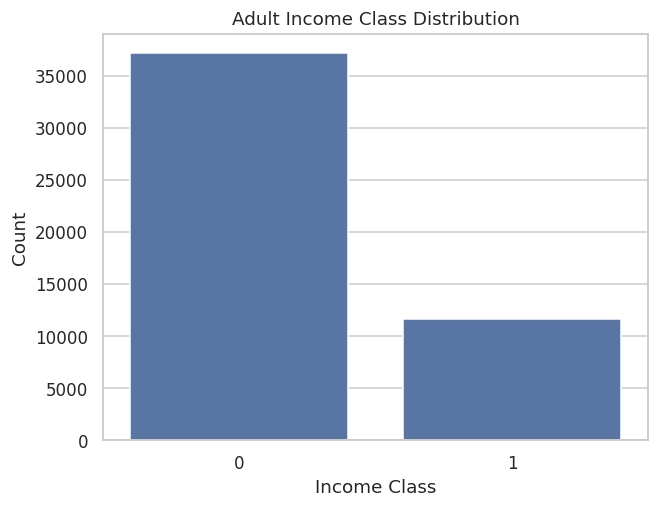

In [42]:
sns.countplot(x=y)

plt.title("Adult Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created.")

Preprocessor created.


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 39073
Testing samples: 9769

Training class distribution:
income
0    0.76073
1    0.23927
Name: proportion, dtype: float64

Testing class distribution:
income
0    0.760672
1    0.239328
Name: proportion, dtype: float64


In [45]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            random_state=SEED,
            n_jobs=-1
        )
    )
])

rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [46]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=SEED
        )
    )
])

lr_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [47]:
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["<=50K", ">50K"]
    ))

    return y_pred, y_prob

In [48]:
rf_pred, rf_prob = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)

lr_pred, lr_prob = evaluate_model(
    lr_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

Random Forest
Accuracy : 0.8544375063977889
Precision: 0.7278606965174129
Recall   : 0.625748502994012
F1-score : 0.672953081876725
ROC-AUC  : 0.9044544569088939

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.73      0.63      0.67      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.85      0.85      9769

Logistic Regression
Accuracy : 0.8504452861091207
Precision: 0.7301837270341207
Recall   : 0.5949529512403764
F1-score : 0.655668159321235
ROC-AUC  : 0.9046208868381237

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7431
        >50K       0.73      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.8

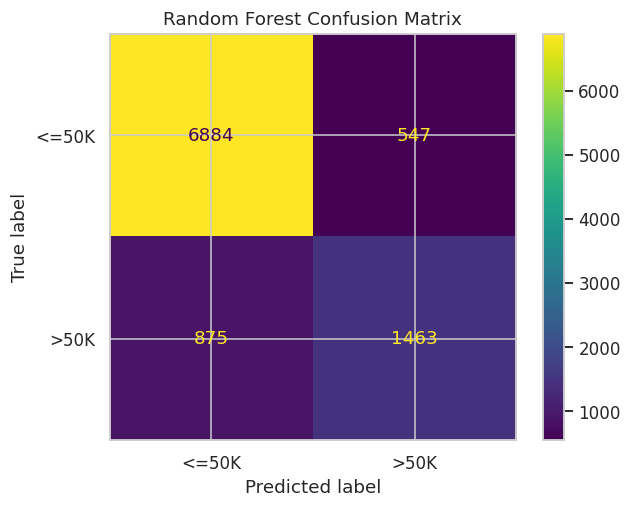

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["<=50K", ">50K"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

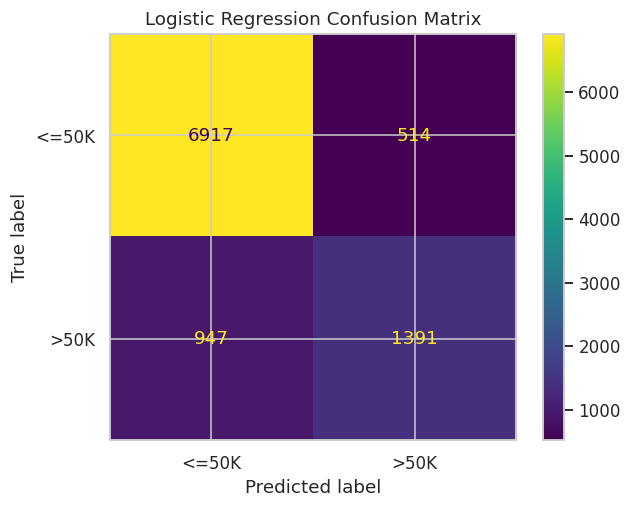

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["<=50K", ">50K"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [51]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, lr_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, lr_pred)
    ],
    "F1": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, lr_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, lr_prob)
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.8544,0.7279,0.6257,0.6730,0.9045
1,Logistic Regression,0.8504,0.7302,0.5950,0.6557,0.9046


In [52]:
preprocessor_lime = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor_lime.fit_transform(X_train)
X_test_processed = preprocessor_lime.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (39073, 108)
Processed testing shape: (9769, 108)


In [53]:
feature_names_lime = (
    preprocessor_lime
    .get_feature_names_out()
    .tolist()
)

print("Number of transformed features:", len(feature_names_lime))
print(feature_names_lime[:20])

Number of transformed features: 108
['num__age', 'num__fnlwgt', 'num__education-num', 'num__capital-gain', 'num__capital-loss', 'num__hours-per-week', 'cat__workclass_Federal-gov', 'cat__workclass_Local-gov', 'cat__workclass_Never-worked', 'cat__workclass_Private', 'cat__workclass_Self-emp-inc', 'cat__workclass_Self-emp-not-inc', 'cat__workclass_State-gov', 'cat__workclass_Without-pay', 'cat__workclass_nan', 'cat__education_10th', 'cat__education_11th', 'cat__education_12th', 'cat__education_1st-4th', 'cat__education_5th-6th']


In [54]:
rf_lime = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1
)

rf_lime.fit(X_train_processed, y_train)

print("LIME Random Forest trained.")

LIME Random Forest trained.


In [55]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_lime.predict(X_test_processed)
    )
)

Accuracy: 0.8544375063977889


In [56]:
explainer = LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names_lime,
    class_names=["<=50K", ">50K"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED
)

print("LIME explainer created.")

LIME explainer created.


In [57]:
selected_indices = [0, 1, 2]

X_selected = X_test_processed[selected_indices]
y_selected = y_test.iloc[selected_indices].to_numpy()

pred_selected = rf_lime.predict(X_selected)
prob_selected = rf_lime.predict_proba(X_selected)

for i in range(3):
    print(f"Instance {i+1}")
    print("Actual:", y_selected[i])
    print("Predicted:", pred_selected[i])
    print("Probability:", prob_selected[i])
    print()

Instance 1
Actual: 0
Predicted: 0
Probability: [1. 0.]

Instance 2
Actual: 0
Predicted: 0
Probability: [0.905 0.095]

Instance 3
Actual: 0
Predicted: 0
Probability: [0.99 0.01]



In [58]:
instance_id = 0

exp = explainer.explain_instance(
    X_test_processed[instance_id],
    rf_lime.predict_proba,
    num_features=10,
    num_samples=5000
)

print("Actual class:", y_test.iloc[instance_id])
print("Predicted class:", rf_lime.predict(X_test_processed[instance_id].reshape(1, -1))[0])

print("\nLIME explanation:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

Actual class: 0
Predicted class: 0

LIME explanation:
num__capital-gain <= -0.14: -0.4847
cat__native-country_Columbia <= 0.00: -0.1185
cat__native-country_Cambodia <= 0.00: -0.1104
cat__marital-status_Married-civ-spouse <= 0.00: -0.0923
num__education-num <= -0.42: -0.0798
num__capital-loss <= -0.22: -0.0779
num__hours-per-week <= -0.04: -0.0717
cat__education_Doctorate <= 0.00: -0.0641
cat__education_Prof-school <= 0.00: -0.0607
cat__native-country_China <= 0.00: -0.0487


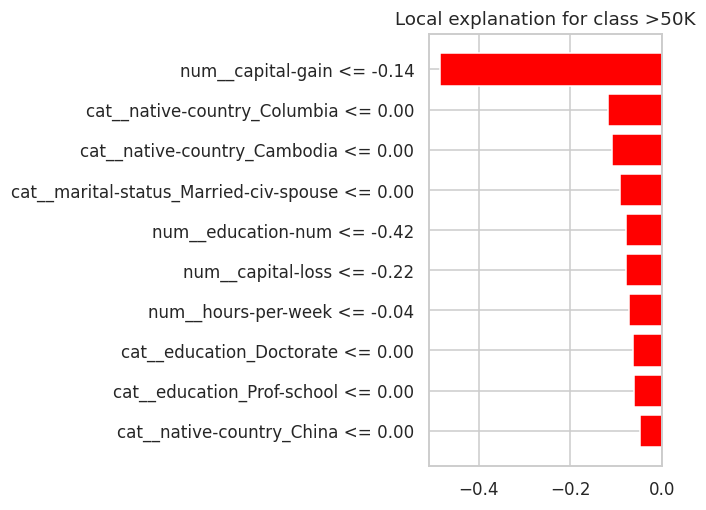

In [59]:
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

In [60]:
explanations = {}

for instance_id in selected_indices:

    exp = explainer.explain_instance(
        X_test_processed[instance_id],
        rf_lime.predict_proba,
        num_features=10,
        num_samples=5000
    )

    explanations[instance_id] = exp

    print("\n" + "=" * 60)
    print("Instance:", instance_id)
    print("Actual:", y_test.iloc[instance_id])
    print(
        "Predicted:",
        rf_lime.predict(
            X_test_processed[instance_id].reshape(1, -1)
        )[0]
    )

    print("\nLIME:")
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")


Instance: 0
Actual: 0
Predicted: 0

LIME:
num__capital-gain <= -0.14: -0.5020
cat__marital-status_Married-civ-spouse <= 0.00: -0.0937
cat__native-country_Thailand <= 0.00: -0.0893
cat__education_Doctorate <= 0.00: -0.0875
cat__marital-status_Married-AF-spouse <= 0.00: -0.0862
cat__workclass_Without-pay <= 0.00: -0.0841
num__capital-loss <= -0.22: -0.0808
num__education-num <= -0.42: -0.0804
cat__native-country_Taiwan <= 0.00: -0.0743
cat__education_Prof-school <= 0.00: -0.0717

Instance: 1
Actual: 0
Predicted: 0

LIME:
num__capital-gain <= -0.14: -0.4775
cat__marital-status_Married-civ-spouse <= 0.00: -0.0946
num__capital-loss <= -0.22: -0.0901
cat__native-country_Hungary <= 0.00: 0.0883
cat__education_Doctorate <= 0.00: -0.0788
cat__education_Prof-school <= 0.00: -0.0749
cat__education_Preschool <= 0.00: -0.0745
cat__native-country_Laos <= 0.00: 0.0683
cat__native-country_Greece <= 0.00: -0.0476
cat__native-country_Trinadad&Tobago <= 0.00: -0.0390

Instance: 2
Actual: 0
Predicted: 0


In [61]:
for instance_id, exp in explanations.items():

    positive = [
        (feature, weight)
        for feature, weight in exp.as_list()
        if weight > 0
    ]

    positive = sorted(
        positive,
        key=lambda x: x[1],
        reverse=True
    )[:5]

    print("\nInstance:", instance_id)
    print("Top 5 positive contributors:")

    for feature, weight in positive:
        print(f"{feature}: {weight:.4f}")


Instance: 0
Top 5 positive contributors:

Instance: 1
Top 5 positive contributors:
cat__native-country_Hungary <= 0.00: 0.0883
cat__native-country_Laos <= 0.00: 0.0683

Instance: 2
Top 5 positive contributors:
cat__workclass_Never-worked <= 0.00: 0.0655
cat__native-country_Haiti <= 0.00: 0.0452
cat__native-country_Cambodia <= 0.00: 0.0452


In [62]:
for instance_id, exp in explanations.items():

    negative = [
        (feature, weight)
        for feature, weight in exp.as_list()
        if weight < 0
    ]

    negative = sorted(
        negative,
        key=lambda x: x[1]
    )[:5]

    print("\nInstance:", instance_id)
    print("Top 5 negative contributors:")

    for feature, weight in negative:
        print(f"{feature}: {weight:.4f}")


Instance: 0
Top 5 negative contributors:
num__capital-gain <= -0.14: -0.5020
cat__marital-status_Married-civ-spouse <= 0.00: -0.0937
cat__native-country_Thailand <= 0.00: -0.0893
cat__education_Doctorate <= 0.00: -0.0875
cat__marital-status_Married-AF-spouse <= 0.00: -0.0862

Instance: 1
Top 5 negative contributors:
num__capital-gain <= -0.14: -0.4775
cat__marital-status_Married-civ-spouse <= 0.00: -0.0946
num__capital-loss <= -0.22: -0.0901
cat__education_Doctorate <= 0.00: -0.0788
cat__education_Prof-school <= 0.00: -0.0749

Instance: 2
Top 5 negative contributors:
num__capital-gain <= -0.14: -0.4719
cat__marital-status_Married-civ-spouse <= 0.00: -0.0963
num__age <= -0.78: -0.0722
cat__education_Prof-school <= 0.00: -0.0716
num__hours-per-week <= -0.04: -0.0694


In [64]:
# Select the first test instance for the stability experiment
stability_idx = 0

print("Stability instance:", stability_idx)
print("Actual class:", y_test.iloc[stability_idx])
print(
    "Predicted class:",
    rf_lime.predict(
        X_test_processed[stability_idx].reshape(1, -1)
    )[0]
)

Stability instance: 0
Actual class: 0
Predicted class: 0


In [65]:
N_RUNS = 10

stability_runs = []

for r in range(N_RUNS):

    explainer_run = LimeTabularExplainer(
        X_train_processed,
        feature_names=feature_names_lime,
        class_names=["<=50K", ">50K"],
        mode="classification",
        discretize_continuous=True,
        random_state=100 + r
    )

    exp = explainer_run.explain_instance(
        X_test_processed[stability_idx],
        rf_lime.predict_proba,
        num_features=5,
        num_samples=5000
    )

    stability_runs.append(dict(exp.as_list()))

print("Completed", N_RUNS, "LIME runs.")

Completed 10 LIME runs.


In [67]:
stability_df = pd.DataFrame(stability_runs).fillna(0)

print("LIME Feature Weights Across 10 Runs:")
display(stability_df.round(4))

LIME Feature Weights Across 10 Runs:


,num__capital-gain <= -0.14,cat__marital-status_Married-civ-spouse <= 0.00,num__hours-per-week <= -0.04,num__education-num <= -0.42,cat__relationship_Husband <= 0.00
0,-0.4884,-0.0900,-0.0741,-0.0720,-0.0499
1,-0.4940,-0.0971,-0.0710,-0.0824,-0.0547
2,-0.4771,-0.0964,-0.0692,-0.0825,-0.0492
3,-0.4904,-0.0928,-0.0708,-0.0773,-0.0495


In [68]:
# Select features that appeared in the explanations
all_features = stability_df.columns

stability_summary = pd.DataFrame({
    "Mean": stability_df[all_features].mean(),
    "Std": stability_df[all_features].std(),
    "Min": stability_df[all_features].min(),
    "Max": stability_df[all_features].max(),
    "Appeared_in_Runs": [
        (stability_df[f] != 0).sum()
        for f in all_features
    ]
})

# Sort by absolute mean contribution
stability_summary = (
    stability_summary
    .sort_values(
        "Mean",
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(stability_summary.round(4))

,Mean,Std,Min,Max,Appeared_in_Runs
num__capital-gain <= -0.14,-0.4875,0.0073,-0.4940,-0.4771,4
cat__marital-status_Married-civ-spouse <= 0.00,-0.0941,0.0033,-0.0971,-0.0900,4
num__education-num <= -0.42,-0.0785,0.0050,-0.0825,-0.0720,4
num__hours-per-week <= -0.04,-0.0713,0.0021,-0.0741,-0.0692,4
cat__relationship_Husband <= 0.00,-0.0508,0.0026,-0.0547,-0.0492,4


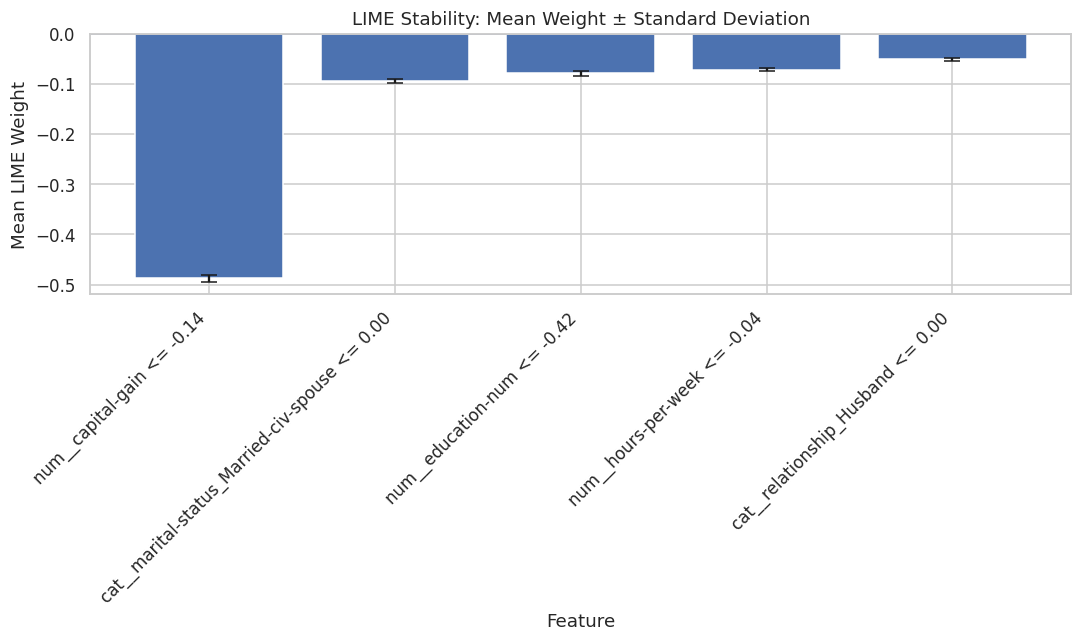

In [69]:
top_features = stability_summary.head(5).index

means = stability_summary.loc[top_features, "Mean"]
stds = stability_summary.loc[top_features, "Std"]

plt.figure(figsize=(10, 6))

plt.bar(
    range(len(top_features)),
    means,
    yerr=stds,
    capsize=5
)

plt.xticks(
    range(len(top_features)),
    top_features,
    rotation=45,
    ha="right"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Feature")
plt.ylabel("Mean LIME Weight")
plt.title("LIME Stability: Mean Weight ± Standard Deviation")

plt.tight_layout()
plt.show()

In [70]:
most_stable = stability_summary["Std"].idxmin()
least_stable = stability_summary["Std"].idxmax()
highest_contribution = stability_summary["Mean"].abs().idxmax()
largest_variation = stability_summary["Std"].idxmax()

print("Most stable feature:", most_stable)
print("Least stable feature:", least_stable)
print("Highest average contribution:", highest_contribution)
print("Largest variation:", largest_variation)

Most stable feature: num__hours-per-week <= -0.04
Least stable feature: num__capital-gain <= -0.14
Highest average contribution: num__capital-gain <= -0.14
Largest variation: num__capital-gain <= -0.14


In [71]:
sample_sizes = [1000, 5000, 10000]

sample_stability = {}

for n_samples in sample_sizes:

    runs = []

    for r in range(10):

        exp = LimeTabularExplainer(
            X_train_processed,
            feature_names=feature_names_lime,
            class_names=["<=50K", ">50K"],
            mode="classification",
            discretize_continuous=True,
            random_state=300 + r
        )

        explanation = exp.explain_instance(
            X_test_processed[stability_idx],
            rf_lime.predict_proba,
            num_features=5,
            num_samples=n_samples
        )

        runs.append(dict(explanation.as_list()))

    df = pd.DataFrame(runs).fillna(0)

    sample_stability[n_samples] = df

    print(f"Completed {n_samples} samples")

Completed 1000 samples
Completed 5000 samples
Completed 10000 samples


In [72]:
comparison_results = []

for n_samples, df in sample_stability.items():

    comparison_results.append({
        "num_samples": n_samples,
        "Average_STD": df.std().mean(),
        "Maximum_STD": df.std().max()
    })

comparison_df = pd.DataFrame(comparison_results)

display(comparison_df.round(4))

,num_samples,Average_STD,Maximum_STD
0,1000,0.0181,0.0279
1,5000,0.0049,0.0128
2,10000,0.0035,0.0087




---



31. **Identify the Most Stable and Least Stable Features**

From the 10-run LIME stability experiment:

Most stable feature: num__hours-per-week <= -0.04
Least stable feature: num__capital-gain <= -0.14
Feature with the highest average contribution: num__capital-gain <= -0.14
Feature with the largest variation: num__capital-gain <= -0.14

The most stable feature has the smallest standard deviation in its LIME weights across the 10 runs. In contrast, num__capital-gain <= -0.14 has the largest variation, indicating that its contribution is more sensitive to the random sampling used by LIME.



---



32. **Explain Why LIME Explanations Vary Between Runs**

LIME explanations can vary between runs because LIME generates random perturbed samples around the instance being explained. Each run can therefore produce a slightly different local neighbourhood and consequently different feature weights.

The main factors responsible for the variation are random sampling, the number of samples used by LIME, the local neighbourhood around the instance, kernel width, and the non-linear behaviour of the Random Forest model.

Therefore, a single LIME explanation should not be treated as completely reliable. Running LIME multiple times and reporting the mean and standard deviation provides a better assessment of explanation stability.



---



### 33. What Happens When the Number of Samples Is Increased?

The results show that increasing `num_samples` makes the LIME explanations more stable.

| Number of Samples | Average STD | Maximum STD |
| ----------------: | ----------: | ----------: |
|             1,000 |      0.0181 |      0.0279 |
|             5,000 |      0.0049 |      0.0128 |
|            10,000 |      0.0035 |      0.0087 |

The average standard deviation decreases from **0.0181** with 1,000 samples to **0.0049** with 5,000 samples and further to **0.0035** with 10,000 samples.

Similarly, the maximum standard deviation decreases from **0.0279** to **0.0128** and finally to **0.0087**.

Therefore, increasing the number of perturbed samples substantially improves the stability of the LIME explanations, although it requires more computation.




---



### 34. Overall Conclusion on LIME Stability

The experiment demonstrates that LIME explanations are affected by the randomness involved in generating the local neighbourhood. The 10-run experiment showed that some features have stable contributions while others, particularly `num__capital-gain <= -0.14`, show greater variation.

Increasing the number of samples significantly improves stability. The average standard deviation decreased from **0.0181 at 1,000 samples** to **0.0049 at 5,000 samples** and **0.0035 at 10,000 samples**.

Thus, for reliable local explanations, LIME should be run with a sufficiently large number of samples and explanations should ideally be evaluated across multiple runs. In this experiment, **10,000 samples produced the most stable explanations**, while **5,000 samples provides a reasonable balance between stability and computational cost**.




---

